<a href="https://colab.research.google.com/github/natitedros/NLP-lab/blob/main/lab_1/imdb_cnn_sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMDb sentiment classification with a 1D CNN (PyTorch)

**Pipeline:** Text → Tokenization → Embedding → 1D CNN → ReLU → Max Pooling → Linear → Positive / Negative

**What this notebook does**

1. Loads `stanfordnlp/imdb` and audits it: class balance, review lengths, HTML noise, duplicates, train/test leakage.
2. Cleans the text, removes duplicates, and makes a stratified train / validation split.
3. Tokenizes, builds a vocabulary from the training split only, and pads every review to a fixed length.
4. Trains the same CNN with three filter sizes (3, 5 and 7 tokens).
5. Reports training loss, training / validation / test accuracy, and a confusion matrix for each filter size.

## 0. Setup

In [1]:
# PyTorch, scikit-learn, pandas and matplotlib ship with Colab; `datasets` may not.
%pip install -q datasets

In [15]:
import copy
import html
import random
import re
import time
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from datasets import load_dataset
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

# ---- every setting lives here ----
SEED = 42
VAL_FRACTION = 0.10        # share of the training data held out for validation
MAX_VOCAB = 25_000         # keep at most this many distinct words
MIN_FREQ = 2               # ...and keep only words in vocabulary if seen at least this often
MAX_LEN = 500              # every review is cut / padded to this many tokens
EMBED_DIM = 100            # size of each word vector
NUM_FILTERS = 100          # number of convolution filters
KERNEL_SIZES = [3, 5, 7]   # the CNN filter sizes being compared
DROPOUT = 0.5              # set to 0.0 for the bare pipeline with no dropout
BATCH_SIZE = 64
EPOCHS = 5
LR = 1e-3


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("Using device:", device)

# ---- plot styling ----
CLASS_COLORS = {"neg": "#2a78d6", "pos": "#eb6834"}
KERNEL_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]
BLUES = LinearSegmentedColormap.from_list(
    "blues", ["#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]
)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#e6e5e1",
    "grid.linewidth": 0.8,
    "axes.edgecolor": "#b5b4ae",
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "lines.linewidth": 2,
    "lines.markersize": 7,
    "legend.frameon": False,
})

Using device: cuda


## 1. Load the dataset

`stanfordnlp/imdb` has three splits. `train` and `test` hold 25,000 labelled reviews each. `unsupervised` holds unlabelled reviews (label `-1`), which a supervised classifier cannot use, so it is left out.

In [3]:
raw = load_dataset("stanfordnlp/imdb")
print(raw)

LABEL_NAMES = raw["train"].features["label"].names   # index 0 -> 'neg', index 1 -> 'pos'
print("\nLabel names:", LABEL_NAMES)

train_df = raw["train"].to_pandas()
test_df = raw["test"].to_pandas()
train_df.head()

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Label names: ['neg', 'pos']


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


## 2. Data audit

Before any modelling, check what is actually in the data. Each check below decides a preprocessing step later.

### 2.1 Structure and missing values

In [4]:
for name, df in [("train", train_df), ("test", test_df)]:
    n_missing = int(df["text"].isna().sum())
    n_empty = int((df["text"].fillna("").str.strip() == "").sum())
    print(
        f"{name:<5} rows={len(df):>6,}  columns={list(df.columns)}  "
        f"missing text={n_missing}  empty text={n_empty}  "
        f"label values={sorted(df['label'].unique().tolist())}"
    )

print("\nOne raw review:\n")
print(train_df.loc[0, "text"][:600], "...")

train rows=25,000  columns=['text', 'label']  missing text=0  empty text=0  label values=[0, 1]
test  rows=25,000  columns=['text', 'label']  missing text=0  empty text=0  label values=[0, 1]

One raw review:

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political is ...


### 2.2 Is the data balanced?

If one class dominated, plain accuracy would be misleading (a model could score well by always predicting the majority class) and we would need class weights or resampling. So this is checked first.

,rows,neg,neg %,pos,pos %
split,,,,,
train,25000,12500,50.0,12500,50.0
test,25000,12500,50.0,12500,50.0


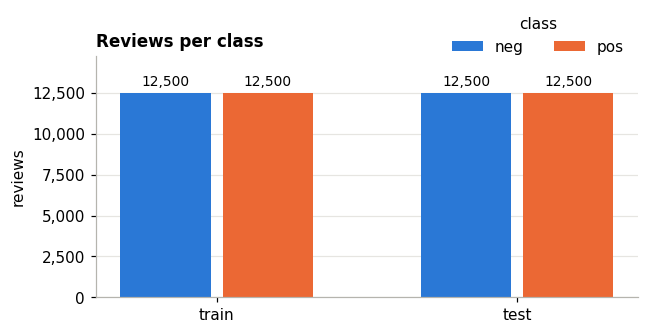

In [5]:
def class_balance(frames):
    """Rows per class and class share for each named DataFrame."""
    rows = []
    for name, df in frames.items():
        counts = df["label"].value_counts().reindex(range(len(LABEL_NAMES)), fill_value=0)
        row = {"split": name, "rows": len(df)}
        for idx, label in enumerate(LABEL_NAMES):
            row[label] = int(counts[idx])
            row[f"{label} %"] = round(100 * counts[idx] / max(len(df), 1), 2)
        rows.append(row)
    return pd.DataFrame(rows).set_index("split")


balance = class_balance({"train": train_df, "test": test_df})
display(balance)

fig, ax = plt.subplots(figsize=(6, 3.2))
x = np.arange(len(balance))
width = 0.3
for i, label in enumerate(LABEL_NAMES):
    offset = (i - (len(LABEL_NAMES) - 1) / 2) * (width + 0.04)
    bars = ax.bar(x + offset, balance[label], width, label=label, color=CLASS_COLORS[label])
    ax.bar_label(bars, labels=[f"{v:,}" for v in balance[label]], padding=3, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(balance.index)
ax.set_ylabel("reviews")
ax.set_ylim(0, balance[LABEL_NAMES].to_numpy().max() * 1.18)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.grid(axis="x", visible=False)
ax.set_title("Reviews per class")
ax.legend(title="class", ncols=2, loc="upper right", bbox_to_anchor=(1, 1.22))
plt.tight_layout()
plt.show()

### 2.3 How long are the reviews?

A CNN in PyTorch needs every review in a batch to have the same length, so a fixed length has to be chosen. The distribution below shows what a given cut-off would throw away. It also shows whether one class is systematically longer than the other, which would be a shortcut the model could exploit.

,train (all),train neg,train pos,test (all)
count,25000.0,12500.0,12500.0,25000.0
mean,233.8,230.9,236.7,228.5
std,173.7,166.7,180.5,168.9
min,10.0,10.0,12.0,4.0
50%,174.0,174.0,174.0,172.0
90%,458.0,441.0,472.0,444.0
95%,598.0,575.0,619.0,582.0
99%,913.0,892.0,924.0,901.0
max,2470.0,1522.0,2470.0,2278.0


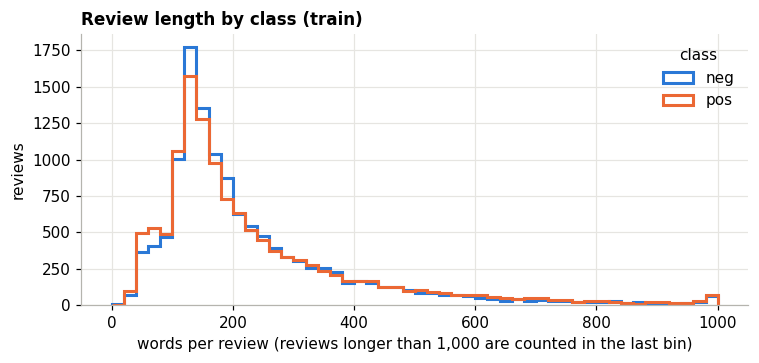

In [6]:
train_df["n_words"] = train_df["text"].str.split().str.len()
test_df["n_words"] = test_df["text"].str.split().str.len()

length_stats = pd.concat(
    {
        "train (all)": train_df["n_words"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]),
        "train neg": train_df.loc[train_df["label"] == 0, "n_words"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]),
        "train pos": train_df.loc[train_df["label"] == 1, "n_words"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]),
        "test (all)": test_df["n_words"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]),
    },
    axis=1,
).round(1)
display(length_stats)

CLIP = 1000   # the tail beyond this is very thin; clip it so the bulk is readable
bins = np.linspace(0, CLIP, 51)
fig, ax = plt.subplots(figsize=(7, 3.4))
for idx, label in enumerate(LABEL_NAMES):
    words = train_df.loc[train_df["label"] == idx, "n_words"].clip(upper=CLIP)
    ax.hist(words, bins=bins, histtype="step", linewidth=2, label=label, color=CLASS_COLORS[label])
ax.set_xlabel(f"words per review (reviews longer than {CLIP:,} are counted in the last bin)")
ax.set_ylabel("reviews")
ax.set_title("Review length by class (train)")
ax.legend(title="class")
plt.tight_layout()
plt.show()

### 2.4 Noise in the text

The reviews were scraped from web pages, so they can carry HTML line breaks (`<br />`), other tags, HTML entities such as `&amp;`, and URLs. None of these say anything about sentiment, and left alone they would become meaningless tokens like `br`.

In [7]:
NOISE_PATTERNS = {
    "<br> line breaks": r"<br\s*/?>",
    "any HTML tag": r"</?[a-zA-Z][^<>]*>",
    "HTML entities (&amp; ...)": r"&[a-zA-Z]+;|&#\d+;",
    "URLs": r"https?://|www\.",
}

noise = pd.DataFrame(
    {
        name: {
            pattern_name: round(100 * df["text"].str.contains(pattern, regex=True).mean(), 2)
            for pattern_name, pattern in NOISE_PATTERNS.items()
        }
        for name, df in [("train", train_df), ("test", test_df)]
    }
)
noise.columns = [f"% of {c} reviews" for c in noise.columns]
display(noise)

,% of train reviews,% of test reviews
<br> line breaks,58.66,58.14
any HTML tag,58.67,58.14
HTML entities (&amp; ...),0.03,0.02
URLs,0.39,0.42


### 2.5 Duplicates and train/test leakage

Three separate questions:

- **Duplicates inside train** over-weight some reviews and can land the same text in both the training and validation split.
- **Conflicting duplicates** (same text, different label) are label noise.
- **Reviews that appear in both train and test** are leakage: the model would be tested on text it has already seen.

In [8]:
def duplicate_report(train, test, column):
    dup_train = int(train.duplicated(column).sum())
    dup_test = int(test.duplicated(column).sum())
    conflicts = int((train.groupby(column)["label"].nunique() > 1).sum())
    shared = set(train[column]) & set(test[column])
    print(f"Exact duplicate rows inside train : {dup_train:,}")
    print(f"Exact duplicate rows inside test  : {dup_test:,}")
    print(f"Train texts with conflicting labels: {conflicts:,}")
    print(f"Distinct texts in both train & test: {len(shared):,} "
          f"(covering {int(train[column].isin(shared).sum()):,} train rows)")


duplicate_report(train_df, test_df, "text")

Exact duplicate rows inside train : 96
Exact duplicate rows inside test  : 199
Train texts with conflicting labels: 0
Distinct texts in both train & test: 123 (covering 123 train rows)


## 3. Preprocessing

### 3.1 Clean the text

Deliberately light cleaning:

- remove HTML tags and decode HTML entities,
- normalise curly apostrophes so `don’t` and `don't` are the same word,
- lowercase,
- collapse repeated whitespace.

Stop words are **not** removed and nothing is stemmed. Words like *not*, *no* and *never* flip the sentiment of a phrase, and a CNN reads short phrases (n-grams), so `not good` has to survive intact.

In [9]:
TAG_RE = re.compile(r"</?[a-zA-Z][^<>]*>")   # matches <br />, <i>, </b> ... but not "<3"
SPACE_RE = re.compile(r"\s+")


def clean_text(text):
    text = TAG_RE.sub(" ", text)                         # drop HTML tags
    text = html.unescape(text)                           # &amp; -> &, &quot; -> "
    text = text.replace("’", "'").replace("`", "'") # one apostrophe style
    text = text.lower()
    return SPACE_RE.sub(" ", text).strip()


train_df["clean"] = train_df["text"].map(clean_text)
test_df["clean"] = test_df["text"].map(clean_text)

example = train_df.loc[train_df["text"].str.contains("<br"), ["text", "clean"]].iloc[0]
print("BEFORE:", example["text"][:300])
print("\nAFTER :", example["clean"][:300])

BEFORE: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h

AFTER : i rented i am curious-yellow from my video store because of all the controversy that surrounded it when it was first released in 1967. i also heard that at first it was seized by u.s. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" i really h


### 3.2 Remove duplicates and leaked reviews

Duplicates are detected on the *cleaned* text, so two copies that differ only in markup or letter case are still caught.

Only the **training** data is changed. The test set is left exactly as published so the test accuracy stays comparable with other results on this benchmark; instead, any training review that also appears in the test set is dropped from training.

In [10]:
n_start = len(train_df)

# 1) reviews that are empty after cleaning
train_df = train_df[train_df["clean"].str.len() > 0]
n_after_empty = len(train_df)

# 2) the same text with two different labels: no way to know which is right, drop all copies
labels_per_text = train_df.groupby("clean")["label"].nunique()
conflicting = set(labels_per_text[labels_per_text > 1].index)
train_df = train_df[~train_df["clean"].isin(conflicting)]
n_after_conflict = len(train_df)

# 3) exact duplicates: keep one copy
train_df = train_df.drop_duplicates("clean")
n_after_dupes = len(train_df)

# 4) leakage: training reviews that also sit in the test set
train_df = train_df[~train_df["clean"].isin(set(test_df["clean"]))].reset_index(drop=True)
n_final = len(train_df)

print(f"Training rows at start            : {n_start:,}")
print(f"  removed, empty after cleaning   : {n_start - n_after_empty:,}")
print(f"  removed, conflicting labels     : {n_after_empty - n_after_conflict:,}")
print(f"  removed, duplicates             : {n_after_conflict - n_after_dupes:,}")
print(f"  removed, also in the test set   : {n_after_dupes - n_final:,}")
print(f"Training rows kept                : {n_final:,} ({100 * n_final / n_start:.2f}%)")

print("\nBalance after cleaning (the test set is untouched):")
display(class_balance({"train (cleaned)": train_df, "test": test_df}))

Training rows at start            : 25,000
  removed, empty after cleaning   : 0
  removed, conflicting labels     : 0
  removed, duplicates             : 98
  removed, also in the test set   : 123
Training rows kept                : 24,779 (99.12%)

Balance after cleaning (the test set is untouched):


,rows,neg,neg %,pos,pos %
split,,,,,
train (cleaned),24779,12336,49.78,12443,50.22
test,25000,12500,50.00,12500,50.00


### 3.3 Train / validation split

The dataset has no validation split, so 10% of the cleaned training data is held out. The split is **stratified**, meaning the positive/negative ratio is the same in both parts. The validation set is used to pick the best epoch and the best filter size; the test set is only used for the final report.

In [11]:
train_part, val_part = train_test_split(
    train_df,
    test_size=VAL_FRACTION,
    stratify=train_df["label"],
    random_state=SEED,
)
train_part = train_part.reset_index(drop=True)
val_part = val_part.reset_index(drop=True)

display(class_balance({"train": train_part, "validation": val_part, "test": test_df}))

overlap = set(train_part["clean"]) & set(val_part["clean"])
print("Reviews shared by train and validation:", len(overlap))

,rows,neg,neg %,pos,pos %
split,,,,,
train,22301,11102,49.78,11199,50.22
validation,2478,1234,49.80,1244,50.20
test,25000,12500,50.00,12500,50.00


Reviews shared by train and validation: 0


### 3.4 Tokenization

A token is a run of letters/digits, optionally with an apostrophe part (`don't`, `it's`). `!` and `?` are kept as their own tokens because they carry tone. All other punctuation is dropped.

In [12]:
TOKEN_RE = re.compile(r"\w+(?:'\w+)*|[!?]")


def tokenize(text):
    return TOKEN_RE.findall(text)


print(tokenize(clean_text("This movie wasn't good... It's GREAT!<br /><br />Don’t miss it?")))

train_tokens = [tokenize(t) for t in train_part["clean"]]
val_tokens = [tokenize(t) for t in val_part["clean"]]
test_tokens = [tokenize(t) for t in test_df["clean"]]
print(f"\nTokenized {len(train_tokens):,} train / {len(val_tokens):,} validation / {len(test_tokens):,} test reviews")

['this', 'movie', "wasn't", 'good', "it's", 'great', '!', "don't", 'miss', 'it', '?']

Tokenized 22,301 train / 2,478 validation / 25,000 test reviews


### 3.5 Vocabulary

Each word is mapped to an integer id. The vocabulary is built from the **training split only**; using validation or test text here would leak information about them into the model. Two special ids are reserved: `<pad>` (0) for padding and `<unk>` (1) for any word not in the vocabulary.

In [13]:
PAD_TOKEN, UNK_TOKEN = "<pad>", "<unk>"
PAD_IDX, UNK_IDX = 0, 1

word_counts = Counter(tok for tokens in train_tokens for tok in tokens)
kept_words = [w for w, c in word_counts.most_common(MAX_VOCAB) if c >= MIN_FREQ]
itos = [PAD_TOKEN, UNK_TOKEN] + kept_words          # id -> word
stoi = {word: idx for idx, word in enumerate(itos)}  # word -> id
VOCAB_SIZE = len(itos)


def unknown_rate(token_lists):
    total = sum(len(t) for t in token_lists)
    unknown = sum(1 for tokens in token_lists for tok in tokens if tok not in stoi)
    return 100 * unknown / max(total, 1)


print(f"Distinct words in training data : {len(word_counts):,}")
print(f"Vocabulary size (with specials) : {VOCAB_SIZE:,}")
print(f"Most common words               : {kept_words[:15]}")
print(f"Tokens mapped to <unk>  train={unknown_rate(train_tokens):.2f}%  "
      f"validation={unknown_rate(val_tokens):.2f}%  test={unknown_rate(test_tokens):.2f}%")

Distinct words in training data : 77,703
Vocabulary size (with specials) : 25,002
Most common words               : ['the', 'and', 'a', 'of', 'to', 'is', 'in', 'it', 'i', 'this', 'that', 'was', 'as', 'for', 'with']
Tokens mapped to <unk>  train=1.91%  validation=2.25%  test=2.68%


### 3.6 Fixed length: truncate and pad

Reviews longer than `MAX_LEN` tokens are cut; shorter ones are filled with `<pad>`. The table shows how many reviews fit completely for a few candidate lengths, which is what justifies the chosen value.

In [16]:
token_lengths = np.array([len(t) for t in train_tokens])
coverage = pd.DataFrame(
    {
        "max_len": [100, 200, 300, 400, 500, 600],
        "% of train reviews that fit entirely": [
            round(100 * (token_lengths <= n).mean(), 1) for n in [100, 200, 300, 400, 500, 600]
        ],
    }
).set_index("max_len")
display(coverage)
print(f"Chosen MAX_LEN = {MAX_LEN}: {100 * (token_lengths <= MAX_LEN).mean():.1f}% of training reviews are not truncated.")


def encode(tokens, max_len=MAX_LEN):
    ids = [stoi.get(tok, UNK_IDX) for tok in tokens[:max_len]]
    return ids + [PAD_IDX] * (max_len - len(ids))


sample = encode(train_tokens[0])
print("\nFirst 12 token ids of one review:", sample[:12])
print("Back to words                    :", [itos[i] for i in sample[:12]])

,% of train reviews that fit entirely
max_len,
100,11.7
200,58.1
300,77.0
400,86.5
500,91.9
600,95.0


Chosen MAX_LEN = 500: 91.9% of training reviews are not truncated.

First 12 token ids of one review: [2, 63, 154, 12, 10548, 11, 499, 37, 111, 4, 957, 1629]
Back to words                    : ['the', 'only', 'thing', 'that', 'prevented', 'this', 'flick', 'from', 'being', 'a', 'total', 'disaster']


### 3.7 Tensors and data loaders

In [17]:
def make_dataset(token_lists, labels):
    X = torch.from_numpy(np.array([encode(tokens) for tokens in token_lists], dtype=np.int64))
    y = torch.from_numpy(np.asarray(labels, dtype=np.int64))
    return TensorDataset(X, y)


train_ds = make_dataset(train_tokens, train_part["label"])
val_ds = make_dataset(val_tokens, val_part["label"])
test_ds = make_dataset(test_tokens, test_df["label"])

# Evaluation loaders never shuffle. The shuffled training loader is created inside
# run_experiment() so every filter size sees the batches in the same order.
train_eval_loader = DataLoader(train_ds, batch_size=256)
val_loader = DataLoader(val_ds, batch_size=256)
test_loader = DataLoader(test_ds, batch_size=256)

X0, y0 = train_ds[0]
print("One example: X", tuple(X0.shape), X0.dtype, "| y", y0.item())
print("Dataset sizes:", len(train_ds), len(val_ds), len(test_ds))

One example: X (500,) torch.int64 | y 0
Dataset sizes: 22301 2478 25000


## 4. The model

One layer per step of the required pipeline:

| Step | Layer | Output shape |
|---|---|---|
| Token ids | input | `(batch, MAX_LEN)` |
| Embedding | `nn.Embedding` | `(batch, MAX_LEN, EMBED_DIM)` |
| 1D CNN | `nn.Conv1d` with `kernel_size = k` | `(batch, NUM_FILTERS, MAX_LEN - k + 1)` |
| ReLU | `nn.ReLU` | same |
| Max pooling | `nn.AdaptiveMaxPool1d(1)` (max over the whole review) | `(batch, NUM_FILTERS)` |
| Linear | `nn.Linear` | `(batch, 2)` → negative / positive |

The filter size `k` is how many consecutive words one filter looks at, so `k = 3` detects 3-word phrases, `k = 5` 5-word phrases, and so on.

Dropout before the linear layer is the one addition to the listed pipeline. It only acts during training, as a regulariser. Set `DROPOUT = 0.0` in the setup cell to remove it.

In [18]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_filters, kernel_size,
                 num_classes=2, dropout=0.5, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.conv = nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=kernel_size)
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters, num_classes)

    def forward(self, x):                  # x: (batch, seq_len) of token ids
        x = self.embedding(x)              # (batch, seq_len, embed_dim)
        x = x.permute(0, 2, 1)             # (batch, embed_dim, seq_len)  Conv1d wants channels first
        x = self.relu(self.conv(x))        # (batch, num_filters, seq_len - k + 1)
        x = self.pool(x).squeeze(2)        # (batch, num_filters)
        x = self.dropout(x)
        return self.fc(x)                  # (batch, num_classes) raw scores (logits)


# Shape check on a tiny batch before training anything
_model = TextCNN(VOCAB_SIZE, EMBED_DIM, NUM_FILTERS, kernel_size=KERNEL_SIZES[0], dropout=DROPOUT, pad_idx=PAD_IDX)
_batch = torch.stack([train_ds[i][0] for i in range(4)])
print(_model)
print("\nInput :", tuple(_batch.shape))
print("Output:", tuple(_model(_batch).shape))
print("Trainable parameters:", f"{sum(p.numel() for p in _model.parameters() if p.requires_grad):,}")
del _model, _batch

TextCNN(
  (embedding): Embedding(25002, 100, padding_idx=0)
  (conv): Conv1d(100, 100, kernel_size=(3,), stride=(1,))
  (relu): ReLU()
  (pool): AdaptiveMaxPool1d(output_size=1)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=100, out_features=2, bias=True)
)

Input : (4, 500)
Output: (4, 2)
Trainable parameters: 2,530,502


## 5. Training and evaluation code

`run_epoch` does one pass over a data loader. With an optimizer it trains; without one it only evaluates. It returns the average loss, the accuracy and the predictions.

`run_experiment` trains one model for a given filter size. After each epoch it checks validation accuracy and keeps a copy of the best weights. The test set is touched once, at the very end, using those best weights.

In [19]:
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train(training)                      # train mode enables dropout, eval mode disables it
    total_loss, n_correct, n_seen = 0.0, 0, 0
    all_preds = []

    with torch.set_grad_enabled(training):
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = criterion(logits, y)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            preds = logits.argmax(dim=1)
            total_loss += loss.item() * y.size(0)
            n_correct += (preds == y).sum().item()
            n_seen += y.size(0)
            all_preds.append(preds.cpu())

    return total_loss / n_seen, n_correct / n_seen, torch.cat(all_preds).numpy()


def run_experiment(kernel_size):
    set_seed(SEED)   # same initial weights and same batch order for every filter size
    model = TextCNN(VOCAB_SIZE, EMBED_DIM, NUM_FILTERS, kernel_size,
                    dropout=DROPOUT, pad_idx=PAD_IDX).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              generator=torch.Generator().manual_seed(SEED))

    history = []
    best_val_acc, best_epoch, best_state = -1.0, 0, None
    print(f"--- filter size {kernel_size} ---")
    for epoch in range(1, EPOCHS + 1):
        start = time.time()
        train_loss, train_acc, _ = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, _ = run_epoch(model, val_loader, criterion)
        history.append({"kernel_size": kernel_size, "epoch": epoch,
                        "train_loss": train_loss, "train_acc": train_acc,
                        "val_loss": val_loss, "val_acc": val_acc})
        if val_acc > best_val_acc:
            best_val_acc, best_epoch = val_acc, epoch
            best_state = copy.deepcopy(model.state_dict())
        print(f"epoch {epoch}/{EPOCHS}  train loss {train_loss:.4f}  train acc {train_acc:.4f}  "
              f"val loss {val_loss:.4f}  val acc {val_acc:.4f}  ({time.time() - start:.0f}s)")

    # Go back to the best epoch and score all three splits the same way (dropout off)
    model.load_state_dict(best_state)
    train_loss, train_acc, _ = run_epoch(model, train_eval_loader, criterion)
    val_loss, val_acc, _ = run_epoch(model, val_loader, criterion)
    test_loss, test_acc, test_preds = run_epoch(model, test_loader, criterion)
    print(f"best epoch {best_epoch}:  train acc {train_acc:.4f}  val acc {val_acc:.4f}  test acc {test_acc:.4f}\n")

    return {
        "kernel_size": kernel_size, "model": model, "history": pd.DataFrame(history),
        "best_epoch": best_epoch,
        "train_loss": train_loss, "train_acc": train_acc,
        "val_loss": val_loss, "val_acc": val_acc,
        "test_loss": test_loss, "test_acc": test_acc,
        "test_preds": test_preds,
        "n_params": sum(p.numel() for p in model.parameters() if p.requires_grad),
    }

## 6. Train one model per filter size

Everything except the filter size is identical across runs (data, seed, embedding size, number of filters, optimizer, epochs), so any difference in the results comes from the filter size.

In [20]:
results = {k: run_experiment(k) for k in KERNEL_SIZES}

--- filter size 3 ---
epoch 1/5  train loss 0.6651  train acc 0.6160  val loss 0.5034  val acc 0.7760  (5s)
epoch 2/5  train loss 0.5317  train acc 0.7327  val loss 0.4377  val acc 0.8204  (2s)
epoch 3/5  train loss 0.4646  train acc 0.7785  val loss 0.3714  val acc 0.8483  (2s)
epoch 4/5  train loss 0.4147  train acc 0.8115  val loss 0.3379  val acc 0.8584  (2s)
epoch 5/5  train loss 0.3655  train acc 0.8394  val loss 0.3245  val acc 0.8616  (2s)
best epoch 5:  train acc 0.9121  val acc 0.8616  test acc 0.8560

--- filter size 5 ---
epoch 1/5  train loss 0.6764  train acc 0.6109  val loss 0.5168  val acc 0.7728  (2s)
epoch 2/5  train loss 0.5302  train acc 0.7308  val loss 0.4293  val acc 0.8216  (2s)
epoch 3/5  train loss 0.4484  train acc 0.7868  val loss 0.3724  val acc 0.8434  (2s)
epoch 4/5  train loss 0.3737  train acc 0.8303  val loss 0.3260  val acc 0.8588  (2s)
epoch 5/5  train loss 0.3111  train acc 0.8676  val loss 0.3129  val acc 0.8680  (3s)
best epoch 5:  train acc 0.942

## 7. Results

### 7.1 Summary table

All numbers in this table come from each model's best epoch (highest validation accuracy), with all three splits scored in evaluation mode.

In [21]:
summary = pd.DataFrame(
    [
        {
            "filter size": r["kernel_size"],
            "best epoch": r["best_epoch"],
            "training loss": r["train_loss"],
            "training accuracy": r["train_acc"],
            "validation accuracy": r["val_acc"],
            "test accuracy": r["test_acc"],
            "parameters": r["n_params"],
        }
        for r in results.values()
    ]
).set_index("filter size")

display(summary.style.format({
    "training loss": "{:.4f}",
    "training accuracy": "{:.2%}",
    "validation accuracy": "{:.2%}",
    "test accuracy": "{:.2%}",
    "parameters": "{:,}",
}))

,best epoch,training loss,training accuracy,validation accuracy,test accuracy,parameters
filter size,,,,,,
3,5,0.2575,91.21%,86.16%,85.60%,"2,530,502"
5,5,0.1880,94.27%,86.80%,86.41%,"2,550,502"
7,4,0.2001,93.79%,85.92%,85.89%,"2,570,502"


### 7.2 Per-epoch history

The training loss and training accuracy logged here are running averages over each epoch while the weights are still being updated (and with dropout on), so they can differ slightly from the summary table above.

train_loss                 train_acc                 val_acc  \
kernel_size          3       5       7         3       5       7       3   
epoch                                                                      
1               0.6651  0.6764  0.6741    0.6160  0.6109  0.6050  0.7760   
2               0.5317  0.5302  0.5213    0.7327  0.7308  0.7362  0.8204   
3               0.4646  0.4484  0.4287    0.7785  0.7868  0.8014  0.8483   
4               0.4147  0.3737  0.3390    0.8115  0.8303  0.8541  0.8584   
5               0.3655  0.3111  0.2719    0.8394  0.8676  0.8875  0.8616   

                             
kernel_size       5       7  
epoch                        
1            0.7728  0.7538  
2            0.8216  0.8148  
3            0.8434  0.8426  
4            0.8588  0.8592  
5            0.8680  0.8571

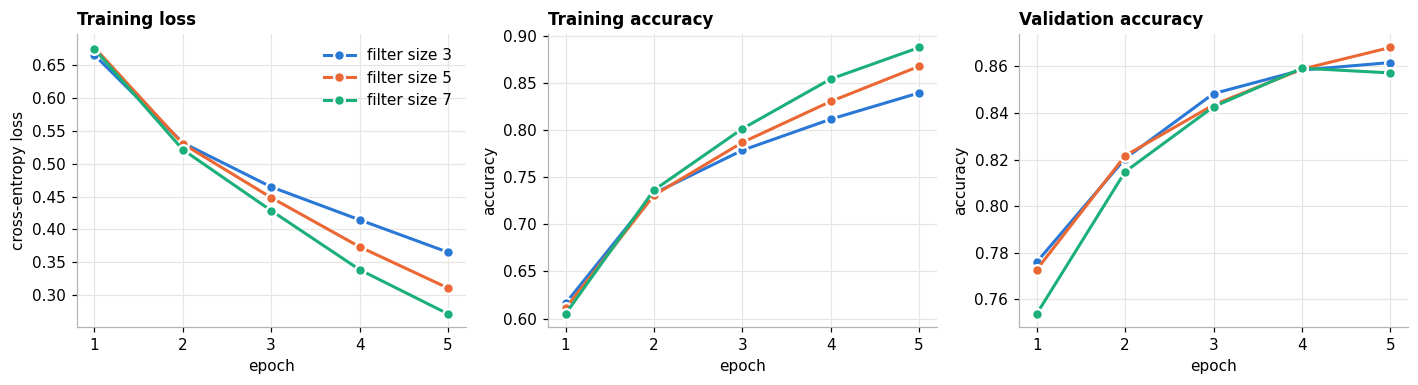

In [22]:
history = pd.concat([r["history"] for r in results.values()], ignore_index=True)
display(
    history.pivot(index="epoch", columns="kernel_size",
                  values=["train_loss", "train_acc", "val_acc"]).round(4)
)

panels = [("train_loss", "Training loss"), ("train_acc", "Training accuracy"), ("val_acc", "Validation accuracy")]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, (column, title) in zip(axes, panels):
    for i, k in enumerate(KERNEL_SIZES):
        h = results[k]["history"]
        ax.plot(h["epoch"], h[column], marker="o", markeredgecolor="white", markeredgewidth=1.5,
                color=KERNEL_COLORS[i % len(KERNEL_COLORS)], label=f"filter size {k}")
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.set_xticks(range(1, EPOCHS + 1))
axes[0].set_ylabel("cross-entropy loss")
axes[1].set_ylabel("accuracy")
axes[2].set_ylabel("accuracy")
axes[0].legend()
plt.tight_layout()
plt.show()

### 7.3 Confusion matrices (test set)

Rows are the true label, columns are the predicted label. The diagonal holds correct predictions. Top-right is false positives (negative reviews called positive); bottom-left is false negatives.

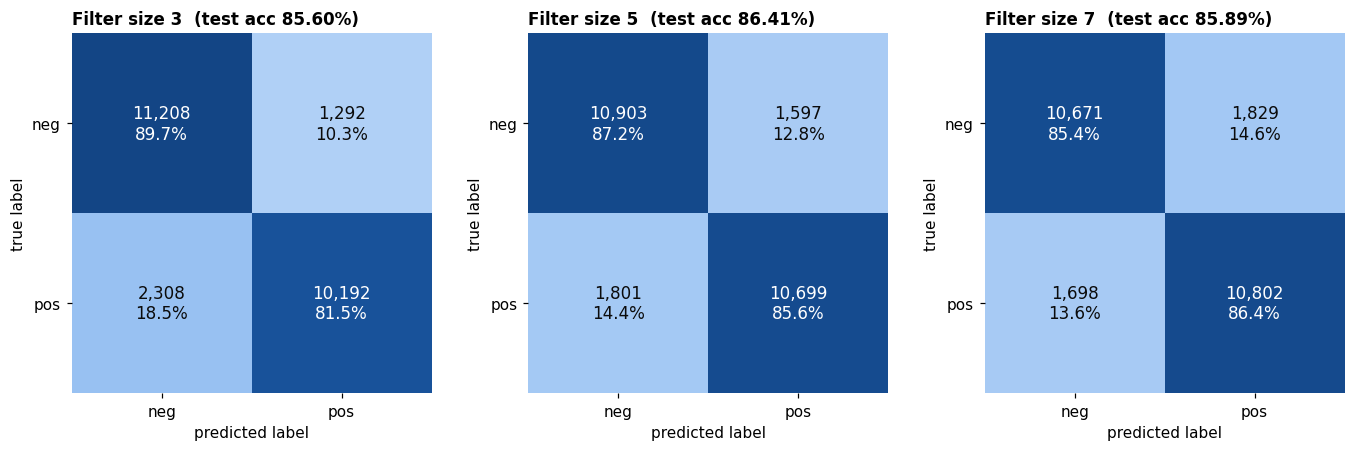

Filter size 3:  TN=11,208  FP=1,292  FN=2,308  TP=10,192
              precision    recall  f1-score   support

         neg     0.8292    0.8966    0.8616     12500
         pos     0.8875    0.8154    0.8499     12500

    accuracy                         0.8560     25000
   macro avg     0.8584    0.8560    0.8558     25000
weighted avg     0.8584    0.8560    0.8558     25000

Filter size 5:  TN=10,903  FP=1,597  FN=1,801  TP=10,699
              precision    recall  f1-score   support

         neg     0.8582    0.8722    0.8652     12500
         pos     0.8701    0.8559    0.8630     12500

    accuracy                         0.8641     25000
   macro avg     0.8642    0.8641    0.8641     25000
weighted avg     0.8642    0.8641    0.8641     25000

Filter size 7:  TN=10,671  FP=1,829  FN=1,698  TP=10,802
              precision    recall  f1-score   support

         neg     0.8627    0.8537    0.8582     12500
         pos     0.8552    0.8642    0.8597     12500

    accurac

In [23]:
y_test = test_df["label"].to_numpy()

fig, axes = plt.subplots(1, len(KERNEL_SIZES), figsize=(4.2 * len(KERNEL_SIZES), 4), squeeze=False)
for ax, k in zip(axes[0], KERNEL_SIZES):
    cm = confusion_matrix(y_test, results[k]["test_preds"], labels=[0, 1])
    ax.imshow(cm, cmap=BLUES, vmin=0, vmax=cm.sum(axis=1).max())
    for i in range(2):
        for j in range(2):
            share = cm[i, j] / cm[i].sum()
            ax.text(j, i, f"{cm[i, j]:,}\n{share:.1%}", ha="center", va="center", fontsize=11,
                    color="white" if share > 0.5 else "#0b0b0b")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(LABEL_NAMES)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(LABEL_NAMES)
    ax.set_xlabel("predicted label")
    ax.set_ylabel("true label")
    ax.set_title(f"Filter size {k}  (test acc {results[k]['test_acc']:.2%})")
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
plt.tight_layout()
plt.show()

for k in KERNEL_SIZES:
    cm = confusion_matrix(y_test, results[k]["test_preds"], labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    print(f"Filter size {k}:  TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
    print(classification_report(y_test, results[k]["test_preds"], target_names=LABEL_NAMES, digits=4))

### 7.4 Which filter size is best?

The choice is made on **validation** accuracy. The test accuracy of the chosen model is then the number to report as the final result, because the test set played no part in choosing it.

In [24]:
best_k = max(results, key=lambda k: results[k]["val_acc"])
best = results[best_k]
print(f"Best filter size by validation accuracy: {best_k}")
print(f"  training loss      : {best['train_loss']:.4f}")
print(f"  training accuracy  : {best['train_acc']:.2%}")
print(f"  validation accuracy: {best['val_acc']:.2%}")
print(f"  test accuracy      : {best['test_acc']:.2%}")

Best filter size by validation accuracy: 5
  training loss      : 0.1880
  training accuracy  : 94.27%
  validation accuracy: 86.80%
  test accuracy      : 86.41%


## 8. Trying it on a custom review text

The same cleaning, tokenization and encoding must be applied to new text before it goes into the model.

In [26]:
def predict_sentiment(text, model=None):
    if model is None:
        model = results[best_k]["model"]
    model.eval()
    ids = torch.tensor([encode(tokenize(clean_text(text)))], dtype=torch.long, device=device)
    with torch.no_grad():
        probs = torch.softmax(model(ids), dim=1).squeeze(0).cpu()
    idx = int(probs.argmax())
    return LABEL_NAMES[idx], float(probs[idx])


for text in [
    "An absolute masterpiece. The acting was superb and I loved every minute.",
    "Dull, predictable and far too long. I want those two hours back.",
    "It was not good, and it was not as funny as people say.",
    "Great! Two hours of my life i can never get back."
]:
    label, confidence = predict_sentiment(text)
    print(f"{label} ({confidence:.1%})  <-  {text}")

pos (77.2%)  <-  An absolute masterpiece. The acting was superb and I loved every minute.
neg (93.9%)  <-  Dull, predictable and far too long. I want those two hours back.
pos (68.7%)  <-  It was not good, and it was not as funny as people say.
pos (57.2%)  <-  Great! Two hours of my life i can never get back.


In [27]:
class TextCNN2(nn.Module):
    """Same as TextCNN, with a second Conv1d + ReLU stacked on top of the first."""

    def __init__(self, vocab_size, embed_dim, num_filters, kernel_size,
                 num_classes=2, dropout=0.5, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.conv1 = nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=kernel_size)
        self.conv2 = nn.Conv1d(in_channels=num_filters, out_channels=num_filters, kernel_size=kernel_size)
        self.relu = nn.ReLU()
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters, num_classes)

    def forward(self, x):                  # x: (batch, seq_len) of token ids
        x = self.embedding(x)              # (batch, seq_len, embed_dim)
        x = x.permute(0, 2, 1)             # (batch, embed_dim, seq_len)
        x = self.relu(self.conv1(x))       # (batch, num_filters, seq_len - k + 1)
        x = self.relu(self.conv2(x))       # (batch, num_filters, seq_len - 2k + 2)
        x = self.pool(x).squeeze(2)        # (batch, num_filters)
        x = self.dropout(x)
        return self.fc(x)                  # (batch, num_classes)


# Shape check before training
_model = TextCNN2(VOCAB_SIZE, EMBED_DIM, NUM_FILTERS, kernel_size=KERNEL_SIZES[0], dropout=DROPOUT, pad_idx=PAD_IDX)
_batch = torch.stack([train_ds[i][0] for i in range(4)])
print(_model)
print("\nInput :", tuple(_batch.shape), " Output:", tuple(_model(_batch).shape))
del _model, _batch

TextCNN2(
  (embedding): Embedding(25002, 100, padding_idx=0)
  (conv1): Conv1d(100, 100, kernel_size=(3,), stride=(1,))
  (conv2): Conv1d(100, 100, kernel_size=(3,), stride=(1,))
  (relu): ReLU()
  (pool): AdaptiveMaxPool1d(output_size=1)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=100, out_features=2, bias=True)
)

Input : (4, 500)  Output: (4, 2)


In [28]:

def run_experiment2(kernel_size):
    set_seed(SEED)
    model = TextCNN2(VOCAB_SIZE, EMBED_DIM, NUM_FILTERS, kernel_size,          # <- only real change
                     dropout=DROPOUT, pad_idx=PAD_IDX).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              generator=torch.Generator().manual_seed(SEED))

    history = []
    best_val_acc, best_epoch, best_state = -1.0, 0, None
    print(f"--- two conv layers, filter size {kernel_size} ---")
    for epoch in range(1, EPOCHS + 1):
        start = time.time()
        train_loss, train_acc, _ = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, _ = run_epoch(model, val_loader, criterion)
        history.append({"kernel_size": kernel_size, "epoch": epoch,
                        "train_loss": train_loss, "train_acc": train_acc,
                        "val_loss": val_loss, "val_acc": val_acc})
        if val_acc > best_val_acc:
            best_val_acc, best_epoch = val_acc, epoch
            best_state = copy.deepcopy(model.state_dict())
        print(f"epoch {epoch}/{EPOCHS}  train loss {train_loss:.4f}  train acc {train_acc:.4f}  "
              f"val loss {val_loss:.4f}  val acc {val_acc:.4f}  ({time.time() - start:.0f}s)")

    model.load_state_dict(best_state)
    train_loss, train_acc, _ = run_epoch(model, train_eval_loader, criterion)
    val_loss, val_acc, _ = run_epoch(model, val_loader, criterion)
    test_loss, test_acc, test_preds = run_epoch(model, test_loader, criterion)
    print(f"best epoch {best_epoch}:  train acc {train_acc:.4f}  val acc {val_acc:.4f}  test acc {test_acc:.4f}\n")

    return {
        "kernel_size": kernel_size, "model": model, "history": pd.DataFrame(history),
        "best_epoch": best_epoch,
        "train_loss": train_loss, "train_acc": train_acc,
        "val_loss": val_loss, "val_acc": val_acc,
        "test_loss": test_loss, "test_acc": test_acc,
        "test_preds": test_preds,
        "n_params": sum(p.numel() for p in model.parameters() if p.requires_grad),
    }

In [29]:
# Separate dict, so the one-layer `results` above stay intact
results2 = {k: run_experiment2(k) for k in KERNEL_SIZES}

--- two conv layers, filter size 3 ---
epoch 1/5  train loss 0.5845  train acc 0.6748  val loss 0.4442  val acc 0.7934  (4s)
epoch 2/5  train loss 0.4107  train acc 0.8137  val loss 0.3462  val acc 0.8503  (4s)
epoch 3/5  train loss 0.3090  train acc 0.8669  val loss 0.3135  val acc 0.8640  (4s)
epoch 4/5  train loss 0.2482  train acc 0.8979  val loss 0.3100  val acc 0.8701  (4s)
epoch 5/5  train loss 0.1928  train acc 0.9246  val loss 0.3191  val acc 0.8680  (4s)
best epoch 4:  train acc 0.9536  val acc 0.8701  test acc 0.8692

--- two conv layers, filter size 5 ---
epoch 1/5  train loss 0.5910  train acc 0.6685  val loss 0.4404  val acc 0.7958  (5s)
epoch 2/5  train loss 0.3913  train acc 0.8256  val loss 0.3636  val acc 0.8398  (5s)
epoch 3/5  train loss 0.2747  train acc 0.8851  val loss 0.3263  val acc 0.8559  (5s)
epoch 4/5  train loss 0.2070  train acc 0.9185  val loss 0.3429  val acc 0.8672  (5s)
epoch 5/5  train loss 0.1482  train acc 0.9433  val loss 0.3496  val acc 0.8664  (

In [30]:
# One-layer vs two-layer, side by side
comparison = pd.DataFrame(
    [
        {
            "filter size": k,
            "conv layers": n_layers,
            "best epoch": r["best_epoch"],
            "training loss": r["train_loss"],
            "training accuracy": r["train_acc"],
            "validation accuracy": r["val_acc"],
            "test accuracy": r["test_acc"],
            "parameters": r["n_params"],
        }
        for n_layers, res in [(1, results), (2, results2)]
        for k, r in res.items()
    ]
).set_index(["filter size", "conv layers"]).sort_index()

display(comparison.style.format({
    "training loss": "{:.4f}",
    "training accuracy": "{:.2%}",
    "validation accuracy": "{:.2%}",
    "test accuracy": "{:.2%}",
    "parameters": "{:,}",
}))


In [31]:
# Confusion matrices for the two-layer models (test set)
y_test = test_df["label"].to_numpy()
for k in KERNEL_SIZES:
    cm = confusion_matrix(y_test, results2[k]["test_preds"], labels=[0, 1])
    print(f"\nTwo conv layers, filter size {k}")
    display(pd.DataFrame(cm, index=[f"true {n}" for n in LABEL_NAMES],
                         columns=[f"predicted {n}" for n in LABEL_NAMES]))


Two conv layers, filter size 3


,predicted neg,predicted pos
true neg,10642,1858
true pos,1413,11087



Two conv layers, filter size 5


,predicted neg,predicted pos
true neg,11074,1426
true pos,1967,10533



Two conv layers, filter size 7


,predicted neg,predicted pos
true neg,10959,1541
true pos,1940,10560


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
